In [152]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from utils.plot_utils import *
from utils.problem import *
from utils.optimizer import *
from utils.homeomorphism import *

In [153]:
class ToyConvexOpt(ConvexOpt):
    def __init__(self, config=None) -> None:
        self.Q = torch.tensor([[1, 0.5], [0.2, 1]], dtype=torch.float32)
        self.p = torch.tensor([0, 0], dtype=torch.float32)
        # Irregular polytope with origin as interior point
        # Various orientations and distances to create asymmetry
        self.A = torch.tensor([
            [1, 0],          # Right: x1 <= 1.5
            [-1, 0],         # Left: -x1 <= 0.8 (x1 >= -0.8)
            [0, 1],          # Top: x2 <= 1.2
            [0, -1],         # Bottom: -x2 <= 0.6 (x2 >= -0.6)
            [1, 1],          # Top-right diagonal: x1 + x2 <= 1.8
            [-1, -1],        # Bottom-left diagonal: -x1 - x2 <= 1.0
            [2, -1],         # Tilted constraint: 2*x1 - x2 <= 2.2
            [-1, 2],         # Another tilted: -x1 + 2*x2 <= 1.5
            [1, -2],         # Bottom-right tilted: x1 - 2*x2 <= 1.8
            [0.5, 1],        # Additional asymmetric: 0.5*x1 + x2 <= 1.3
        ], dtype=torch.float32)
        self.b = torch.tensor([1.5, 0.8, 1.2, 0.6, 1.8, 1.0, 2.2, 1.5, 1.8, 1.3], dtype=torch.float32)
        self.L = torch.tensor([-2, -2], dtype=torch.float32)  # Extended bounds for visualization
        self.U = torch.tensor([2, 2], dtype=torch.float32)
        self.Qq = torch.tensor([[[0.3, 0.1], [0.2, 2]]], dtype=torch.float32)
        self.pq = torch.tensor([[-0.1, -0.2]], dtype=torch.float32)
        self.bq = torch.tensor([[0.2]], dtype=torch.float32)
        # self.Qq = self.pq = self.bq = 
        self.G = self.h = self.C = self.d = None
        self.nvar = 2
        self.ncon = 11  # Updated to reflect 10 inequality constraints
        self.ineq_cons = range(self.ncon)
        self.eq_cons = None
    def __str__(self):
        return 'ToyConvexOpt'
    def to_device(self, device):
        return self

QP = ToyConvexOpt(config=None)
Star = ToyStarOpt(alpha=0.6, num_star=4)
hom_map = GaugeMap(QP, p_norm=2, x_origin=[0.3,0.3], smooth=False)
Star_hom_map = StarMap(Star, p_norm=2, x_origin=[0.,0.])

In [154]:
hom_color = 'royalblue'
ori_color = 'brown'

def _setup_base_plot(problem, hom_map):
    """Helper function to set up the base plot with contours."""
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 5))
    fig1, ax1 = plt.subplots(1, 1, figsize=(5, 5))
    fig2, ax2 = plt.subplots(1, 1, figsize=(5, 5))
    
    # Create grid
    x = np.linspace(-1.5, 1.5, 300)  # Reduced grid size for efficiency
    y = np.linspace(-1.5, 1.5, 300)
    X, Y = np.meshgrid(x, y)
    points = np.stack([X, Y], axis=-1).reshape(-1, 2)
    
    # Generate boundary points
    theta = np.linspace(0, 2 * np.pi, 300)
    boundary = np.column_stack((np.cos(theta), np.sin(theta)))
    K = hom_map.forward(torch.as_tensor(boundary, dtype=torch.float32)).numpy()
    
    # Compute objective values vectorized
    Z_trans = problem.objective_x(hom_map.forward(torch.as_tensor(points, dtype=torch.float32))).numpy().reshape(X.shape)
    Z_orig = problem.objective_x(torch.as_tensor(points, dtype=torch.float32)).numpy().reshape(X.shape)
    # normalzing the objective values
    Z_trans = Z_trans - (Z_trans).min()
    Z_orig = Z_orig - (Z_orig).min()
    
    # Calculate automatic levels based on objective values
    max_val = max(Z_trans.max(), Z_orig.max())
    levels = np.logspace(-2, np.log10(max_val), 10)

    return (fig1,fig2), (ax1, ax2), boundary, K, X, Y, Z_trans, Z_orig, levels

def _plot_equality_constraints(ax1, ax2, hom_map):
    """Helper function to plot equality constraints."""
    # Plot equality constraints
    # x_2 = sin (x_1)
    x_1 = np.linspace(-2., 2., 300)
    x_2 = - 0.8 * x_1 + 0.8
    # x_2 = np.sigmoid(2* x_1) * 0.4
    ax2.plot(x_1, x_2, '-', color=ori_color, label='xeq', linewidth=3, alpha=0.7)

    x = np.column_stack((x_1, x_2))
    z = hom_map.inverse(torch.as_tensor(x, dtype=torch.float32)).numpy()
    ax1.plot(z[:, 0], z[:, 1], '-', color=hom_color, label='zeq', linewidth=3, alpha=0.7)
    
def _plot_contours_and_boundary(ax1, ax2, boundary, K, X, Y, Z_trans, Z_orig, levels):
    """Helper function to plot contours and boundaries."""
    # Left plot (Z-space)
    ax1.plot(boundary[:, 0], boundary[:, 1], '-', color=hom_color, label='Unit Ball B', linewidth=1, alpha=0.7)
    ax1.fill(boundary[:, 0], boundary[:, 1], hom_color, alpha=0.1)
    contour1 = ax1.contour(X, Y, Z_trans,  colors='black', levels=levels, alpha=0.8, linewidths=0.7)
    ax1.clabel(contour1, inline=True, fontsize=8, fmt='%.2f')
    
    # Right plot (X-space)
    ax2.plot(K[:, 0], K[:, 1], '-', color=ori_color, label='Transformed Set K', linewidth=1, alpha=0.7)
    ax2.fill(K[:, 0], K[:, 1], ori_color, alpha=0.1)
    contour2 = ax2.contour(X, Y, Z_orig,  colors='black', levels=levels, alpha=0.8, linewidths=0.7)
    ax2.clabel(contour2, inline=True, fontsize=8, fmt='%.2f')
    
    return contour1, contour2

def _setup_axes(ax1, ax2, bound = 2):
    """Helper function to set up axes properties."""
    # for ax in [ax1, ax2]:
    ax1.set_xlabel('z₁', fontsize=17, fontweight='bold', color=hom_color)
    ax1.set_ylabel('z₂', fontsize=17, fontweight='bold', color=hom_color)
    ax2.set_xlabel('x₁', fontsize=17, fontweight='bold', color=ori_color)
    ax2.set_ylabel('x₂', fontsize=17, fontweight='bold', color=ori_color)
    ax1.set_aspect('equal', 'box')
    ax2.set_aspect('equal', 'box')

    ax1.set_xlim([-bound,bound])
    ax2.set_xlim([-bound,bound])
    ax1.set_ylim([-bound,bound])
    ax2.set_ylim([-bound,bound])

    # Add mathematical text annotations for constraint sets
    # Z-space annotations
    ax1.text(0.55, 0.075, r'$\mathbf{z} \in \mathcal{B}$', 
             transform=ax1.transAxes, fontsize=16, verticalalignment='bottom',
             horizontalalignment='right', color=hom_color, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hom_color))
    
    ax1.text(0.02, 0.98, r'$\phi(\mathbf{z}) = 0$', 
             transform=ax1.transAxes, fontsize=16, verticalalignment='top',
             horizontalalignment='left', color=hom_color, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=hom_color))
    
    # X-space annotations
    ax2.text(0.55, 0.19, r'$\mathbf{x} \in \mathcal{C}$', 
             transform=ax2.transAxes, fontsize=16, verticalalignment='bottom',
             horizontalalignment='right', color=ori_color, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=ori_color))
    
    ax2.text(0.02, 0.98, r'$\varphi(\mathbf{x}) = 0$', 
             transform=ax2.transAxes, fontsize=16, verticalalignment='top',
             horizontalalignment='left', color=ori_color, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=ori_color))
    
    # ax1.grid(True, alpha=0.3)
    # ax1.set_title('Z-space (Unit Ball)\nwith Transformed Objective', fontsize=14)
    # ax2.set_title('X-space (Transformed Set)\nwith Original Objective', fontsize=14)

def plot_both_spaces(problem, hom_map):
    """Plot both spaces with objective contours."""
    (fig1,fig2), (ax1, ax2), boundary, K, X, Y, Z_trans, Z_orig, levels = _setup_base_plot(problem, hom_map)
    _plot_equality_constraints(ax1, ax2, hom_map)
    _plot_contours_and_boundary(ax1, ax2, boundary, K, X, Y, Z_trans, Z_orig, levels)
    _setup_axes(ax1, ax2, bound = 1.5)
    plt.tight_layout()
    return fig1,fig2, ax1, ax2
    


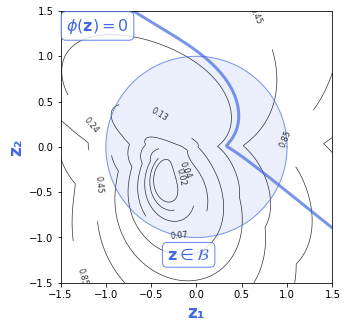

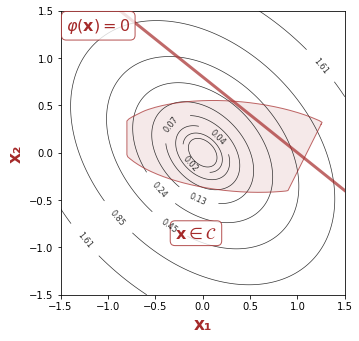

In [ ]:
fig1,fig2, ax1, ax2 = plot_both_spaces(QP, hom_map)
fig1.savefig('pics/test_hom.pdf', bbox_inches='tight')
fig2.savefig('pics/test_ori.pdf', bbox_inches='tight')

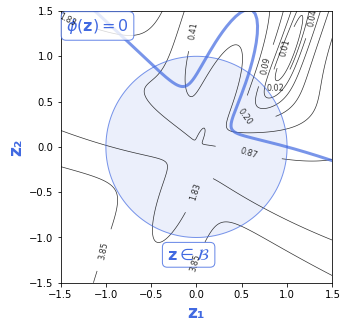

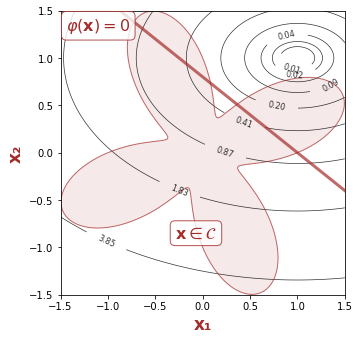

In [ ]:
fig1,fig2, ax1, ax2 = plot_both_spaces(Star, Star_hom_map)
fig1.savefig('pics/star_hom.pdf', bbox_inches='tight')
fig2.savefig('pics/star_ori.pdf', bbox_inches='tight')

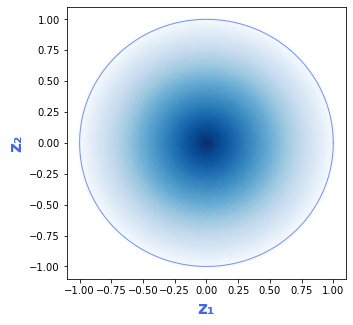

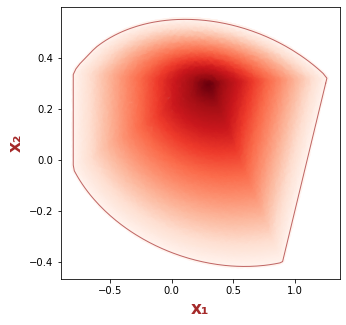

In [157]:
z = np.random.uniform(-1., 1., (200000, 2))
radius = np.linalg.norm(z, axis=1)
z = z[radius < 1.]
radius = radius[radius < 1.]
x = hom_map.forward(torch.as_tensor(z, dtype=torch.float32)).numpy()
# Invert radius so larger values get lighter colors
color_values = 1 - radius

(fig1,fig2), (ax1, ax2), boundary, K, X, Y, Z_trans, Z_orig, levels = _setup_base_plot(QP, hom_map)
ax1.set_xlabel('z₁', fontsize=17, fontweight='bold', color=hom_color)
ax1.set_ylabel('z₂', fontsize=17, fontweight='bold', color=hom_color)
ax2.set_xlabel('x₁', fontsize=17, fontweight='bold', color=ori_color)
ax2.set_ylabel('x₂', fontsize=17, fontweight='bold', color=ori_color)
# ax1.set_aspect('equal', 'box')
# ax2.set_aspect('equal', 'box')

# ax1.set_xlim([-1.,1.])
# ax2.set_xlim([-1.,1.])
# ax1.set_ylim([-1.,1.])
# ax2.set_ylim([-1.,1.])
ax1.plot(boundary[:, 0], boundary[:, 1], '-', color=hom_color, label='Unit Ball B', linewidth=1, alpha=0.7)
ax2.plot(K[:, 0], K[:, 1], '-', color=ori_color, label='Transformed Set K', linewidth=1, alpha=0.7)

ax1.scatter(z[:, 0], z[:, 1], c=color_values, s=20, cmap='Blues', linewidth=0, alpha=0.3, vmin=0, vmax=1)
ax2.scatter(x[:, 0], x[:, 1], c=color_values, s=20, cmap='Reds', linewidth=0, alpha=0.3, vmin=0, vmax=1)


fig1.savefig('pics/ball.png', dpi=300, bbox_inches='tight')
fig2.savefig('pics/poly.png', dpi=300, bbox_inches='tight')